## Exercise 1: Variational Autoencoder (VAE)
**Dataset Used:** Fashion-MNIST (keras.datasets)

1. Implement VAE with reparameterization trick.
2. Implement VAE-Loss and train.
3. Visualize 2D-Latentspace.

## Dataset Validation
Run this cell to verify that your datasets are present and correctly formatted.

In [ ]:
# --- DATASET VALIDATION ---
import os
import pandas as pd

def validate_dataset(filepath, expected_columns=None, avoid_columns=None):
    if not os.path.exists(filepath):
        print(f'❌ ERROR: Dataset not found at {filepath}')
        return False
    try:
        df = pd.read_csv(filepath, nrows=5)
        print(f'✅ SUCCESS: Dataset found at {filepath} (Columns: {df.shape[1]})')
        if expected_columns:
            missing = [c for c in expected_columns if c not in df.columns]
            if missing:
                print(f'⚠️ WARNING: Missing expected columns: {missing}')
                return False
        if avoid_columns:
            forbidden = [c for c in avoid_columns if c in df.columns]
            if forbidden:
                print(f'❌ ERROR: Found forbidden columns {forbidden}. Wrong dataset!')
                return False
        return True
    except Exception as e:
        print(f'❌ ERROR: Could not read dataset: {e}')
        return False

print('Validation helper loaded. Call validate_dataset(path) before loading your data.')
# validate_dataset('../data/your_dataset.csv')

  1/469 ━━━━━━━━━━━━━━━━━━━━ 7:57 1s/step - loss: 544.7986

 12/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 533.9879 

 27/469 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 511.2565

 41/469 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 493.0489

 55/469 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 477.5951

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


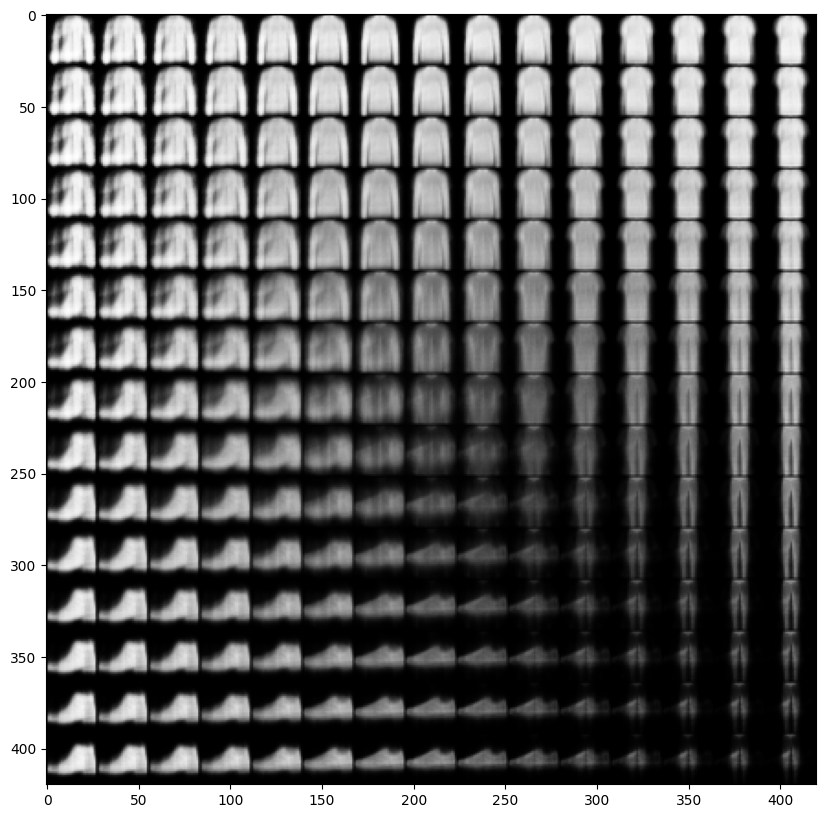

In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Lambda, Flatten, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.losses import binary_crossentropy

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))

latent_dim = 2

inputs = Input(shape=(784,))
h = Dense(256, activation='relu')(inputs)
z_mean = Dense(latent_dim)(h)
z_log_var = Dense(latent_dim)(h)

def sampling(args):
    z_mean, z_log_var = args
    batch = K.shape(z_mean)[0]
    dim = K.int_shape(z_mean)[1]
    epsilon = K.random_normal(shape=(batch, dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

z = Lambda(sampling, output_shape=(latent_dim,))([z_mean, z_log_var])
encoder = Model(inputs, [z_mean, z_log_var, z], name='encoder')

latent_inputs = Input(shape=(latent_dim,))
x = Dense(256, activation='relu')(latent_inputs)
outputs = Dense(784, activation='sigmoid')(x)
decoder = Model(latent_inputs, outputs, name='decoder')

class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
    @property
    def metrics(self):
        return [self.total_loss_tracker]
    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(data, reconstruction)
            ) * 784
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1)
            )
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        return {"loss": self.total_loss_tracker.result()}
    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')
vae.fit(x_train, epochs=1, batch_size=128)

# Visualize 2D Latent space
n = 15
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))
grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(-3, 3, n)

for i, yi in enumerate(grid_x):
    for j, xi in enumerate(grid_y):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size,
               j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gray')
plt.show()